In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("data/warehouse_operations_dataset_v2.csv")
df.head()

,Equipment,Date_Time,Warehouse_Location,InHouse_Location,Issue,Reported_By,Department,Safety_Effected,Operations_Effected,Repaired_By,Repaired_By_Name,Cost,Repair_Date_Time,Downtime_Hours,Month,Day_of_Week,Year
0,Robot,03/22/24 01:39,Bakersfield,VNA,Navigation Error,Supervisor,Maintenance,No,No,Vendor,Malin USA,6252.27,03/24/24 19:39,66.0,3,Friday,2024
1,CubiScan,01/22/24 16:44,Nashville,VNA,Scale Drift,Safety Lead,Quality,Yes,Yes,In House,B. Thomas,1423.78,01/23/24 11:44,19.0,1,Monday,2024
2,Wrap Machine,11/23/24 02:29,Fort Worth,Lab,Sensor Misalignment,Operations Manager,Engineering,No,Yes,In House,T. Moore,609.81,11/23/24 09:29,7.0,11,Saturday,2024
3,Forklift,10/03/24 15:42,San Diego,Pack,Battery Failure,Safety Lead,Safety,No,No,In House,D. Taylor,1043.03,10/03/24 18:42,3.0,10,Thursday,2024
4,Pallet Rack,08/01/24 11:39,Nashville,Inbound,Guard Rail Damage,Operator,Operations,No,No,In House,R. Brown,507.58,08/01/24 15:39,4.0,8,Thursday,2024


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

Shape: (30000, 17)

Columns:
['Equipment', 'Date_Time', 'Warehouse_Location', 'InHouse_Location', 'Issue', 'Reported_By', 'Department', 'Safety_Effected', 'Operations_Effected', 'Repaired_By', 'Repaired_By_Name', 'Cost', 'Repair_Date_Time', 'Downtime_Hours', 'Month', 'Day_of_Week', 'Year']

Data types:
Equipment               object
Date_Time               object
Warehouse_Location      object
InHouse_Location        object
Issue                   object
Reported_By             object
Department              object
Safety_Effected         object
Operations_Effected     object
Repaired_By             object
Repaired_By_Name        object
Cost                   float64
Repair_Date_Time        object
Downtime_Hours         float64
Month                    int64
Day_of_Week             object
Year                     int64
dtype: object

Missing values:
Equipment              0
Repaired_By            0
Day_of_Week            0
Month                  0
Downtime_Hours         0
Repair_Date_T

In [5]:
df["Date_Time"] = pd.to_datetime(df["Date_Time"], format="%m/%d/%y %H:%M", errors="coerce")
df["Repair_Date_Time"] = pd.to_datetime(df["Repair_Date_Time"], format="%m/%d/%y %H:%M", errors="coerce")

print(df[["Date_Time", "Repair_Date_Time"]].dtypes)
df[["Date_Time", "Repair_Date_Time"]].head()

Date_Time           datetime64[ns]
Repair_Date_Time    datetime64[ns]
dtype: object


,Date_Time,Repair_Date_Time
0,2024-03-22 01:39:00,2024-03-24 19:39:00
1,2024-01-22 16:44:00,2024-01-23 11:44:00
2,2024-11-23 02:29:00,2024-11-23 09:29:00
3,2024-10-03 15:42:00,2024-10-03 18:42:00
4,2024-08-01 11:39:00,2024-08-01 15:39:00


In [6]:
df["High_Downtime"] = (df["Downtime_Hours"] > 24).astype(int)
df["High_Downtime"].value_counts()

0    18004
1    11996
Name: High_Downtime, dtype: int64

In [7]:
## 1 if downtime was greater than 24 hours
## 0 if not

In [8]:
class_counts = df["High_Downtime"].value_counts().sort_index()
class_pct = df["High_Downtime"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "Count": class_counts,
    "Percent": class_pct.round(2)
})
summary.index = ["Not High Downtime (0)", "High Downtime (1)"]
summary

,Count,Percent
Not High Downtime (0),18004,60.01
High Downtime (1),11996,39.99


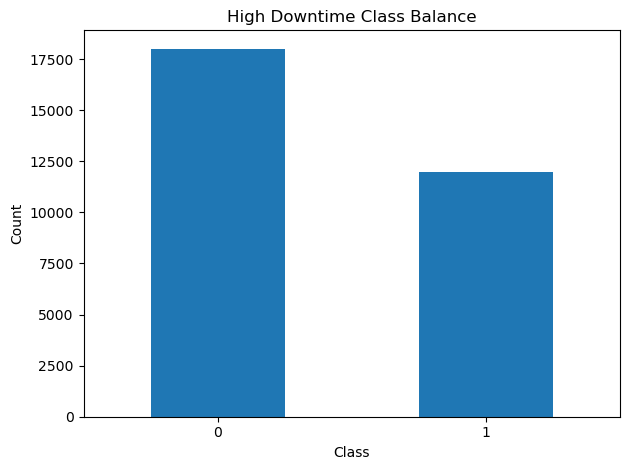

In [9]:
class_counts.plot(kind="bar")
plt.title("High Downtime Class Balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

In [10]:
df["Issue_Hour"] = df["Date_Time"].dt.hour
df["Issue_Month"] = df["Date_Time"].dt.month
df["Issue_DayOfWeek"] = df["Date_Time"].dt.day_name()
df["Weekend_Flag"] = np.where(df["Issue_DayOfWeek"].isin(["Saturday", "Sunday"]), "Weekend", "Weekday")

df[["Issue_Hour", "Issue_Month", "Issue_DayOfWeek", "Weekend_Flag"]].head()

,Issue_Hour,Issue_Month,Issue_DayOfWeek,Weekend_Flag
0,1,3,Friday,Weekday
1,16,1,Monday,Weekday
2,2,11,Saturday,Weekend
3,15,10,Thursday,Weekday
4,11,8,Thursday,Weekday


In [11]:
equipment_risk = (
    df.groupby("Equipment")["High_Downtime"]
      .mean()
      .sort_values(ascending=False)
      .mul(100)
      .round(2)
      .reset_index(name="High_Downtime_Rate_Pct")
)

equipment_risk.head(10)

,Equipment,High_Downtime_Rate_Pct
0,Air Compressor,84.63
1,Scale,64.50
2,Case Erector,48.96
3,Conveyor,46.57
4,Sorter,44.61
5,Robot,41.25
6,Tape Machine,32.69
7,Forklift,32.36
8,Pallet Jack,31.59
9,Print & Apply,30.62


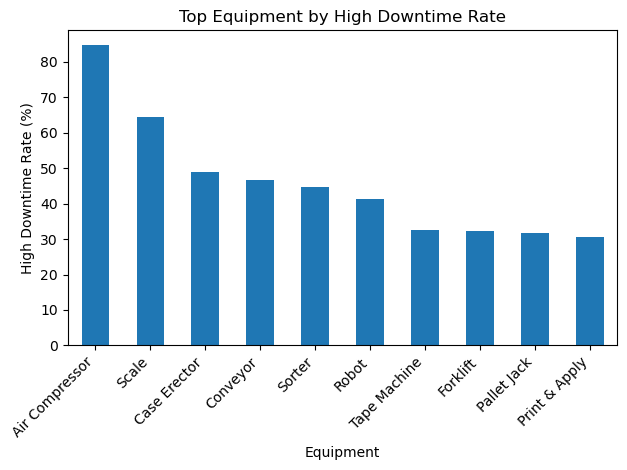

In [12]:
equipment_risk.head(10).plot(kind="bar", x="Equipment", y="High_Downtime_Rate_Pct", legend=False)
plt.title("Top Equipment by High Downtime Rate")
plt.xlabel("Equipment")
plt.ylabel("High Downtime Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
issue_risk = (
    df.groupby("Issue")["High_Downtime"]
      .mean()
      .sort_values(ascending=False)
      .mul(100)
      .round(2)
      .reset_index(name="High_Downtime_Rate_Pct")
)

issue_risk.head(10)

,Issue,High_Downtime_Rate_Pct
0,Oil Leak,89.67
1,Filter Restriction,85.45
2,Certification Due,85.23
3,Low Pressure,84.77
4,Motor Overheat,83.13
5,Scale Calibration,82.39
6,Drain Fault,80.67
7,Case Feed Jam,50.71
8,Tape Head Jam,48.57
9,Vacuum Loss,48.34


In [14]:
feature_cols = [
    "Equipment",
    "Warehouse_Location",
    "InHouse_Location",
    "Issue",
    "Reported_By",
    "Department",
    "Safety_Effected",
    "Operations_Effected",
    "Repaired_By",
    "Repaired_By_Name",
    "Issue_Hour",
    "Issue_Month",
    "Issue_DayOfWeek",
    "Weekend_Flag"
]

target_col = "High_Downtime"

X = df[feature_cols].copy()
y = df[target_col].copy()

X.head()

,Equipment,Warehouse_Location,InHouse_Location,Issue,Reported_By,Department,Safety_Effected,Operations_Effected,Repaired_By,Repaired_By_Name,Issue_Hour,Issue_Month,Issue_DayOfWeek,Weekend_Flag
0,Robot,Bakersfield,VNA,Navigation Error,Supervisor,Maintenance,No,No,Vendor,Malin USA,1,3,Friday,Weekday
1,CubiScan,Nashville,VNA,Scale Drift,Safety Lead,Quality,Yes,Yes,In House,B. Thomas,16,1,Monday,Weekday
2,Wrap Machine,Fort Worth,Lab,Sensor Misalignment,Operations Manager,Engineering,No,Yes,In House,T. Moore,2,11,Saturday,Weekend
3,Forklift,San Diego,Pack,Battery Failure,Safety Lead,Safety,No,No,In House,D. Taylor,15,10,Thursday,Weekday
4,Pallet Rack,Nashville,Inbound,Guard Rail Damage,Operator,Operations,No,No,In House,R. Brown,11,8,Thursday,Weekday


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 24000
Test rows: 6000


In [16]:
categorical_features = [
    "Equipment",
    "Warehouse_Location",
    "InHouse_Location",
    "Issue",
    "Reported_By",
    "Department",
    "Safety_Effected",
    "Operations_Effected",
    "Repaired_By",
    "Repaired_By_Name",
    "Issue_DayOfWeek",
    "Weekend_Flag"
]

numeric_features = [
    "Issue_Hour",
    "Issue_Month"
]

In [17]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features)
    ]
)

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf_model)
])

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [19]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions created.")

Predictions created.


In [20]:
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", round(roc_auc, 4))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      3601
           1       0.93      0.84      0.88      2399

    accuracy                           0.91      6000
   macro avg       0.92      0.90      0.91      6000
weighted avg       0.91      0.91      0.91      6000

ROC AUC: 0.9538


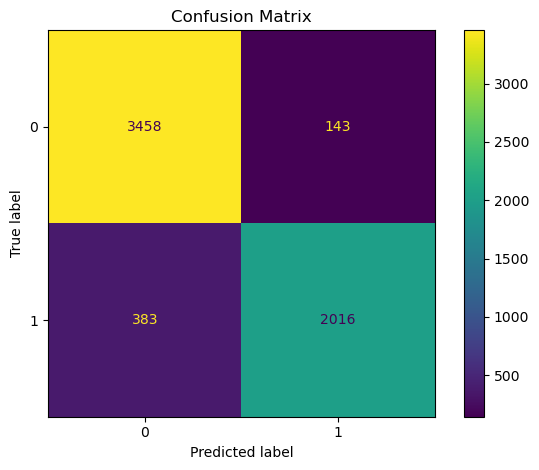

In [21]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

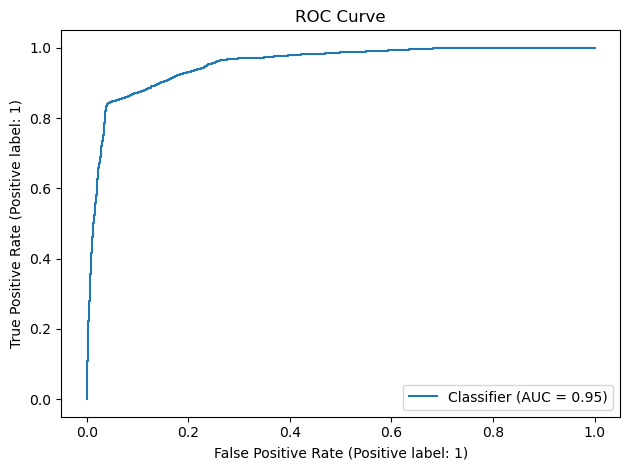

In [22]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

In [23]:
ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = list(cat_feature_names) + numeric_features

importances = model.named_steps["classifier"].feature_importances_

feature_importance_df = (
    pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

feature_importance_df.head(20)

,Feature,Importance
103,Repaired_By_In House,0.274581
104,Repaired_By_Vendor,0.253280
118,Repaired_By_Name_Malin USA,0.113812
132,Issue_Hour,0.017355
101,Operations_Effected_No,0.017247
111,Repaired_By_Name_JP Bowlin,0.015904
133,Issue_Month,0.014571
102,Operations_Effected_Yes,0.014261
113,Repaired_By_Name_Kiesser,0.012026
2,Equipment_Conveyor,0.010347


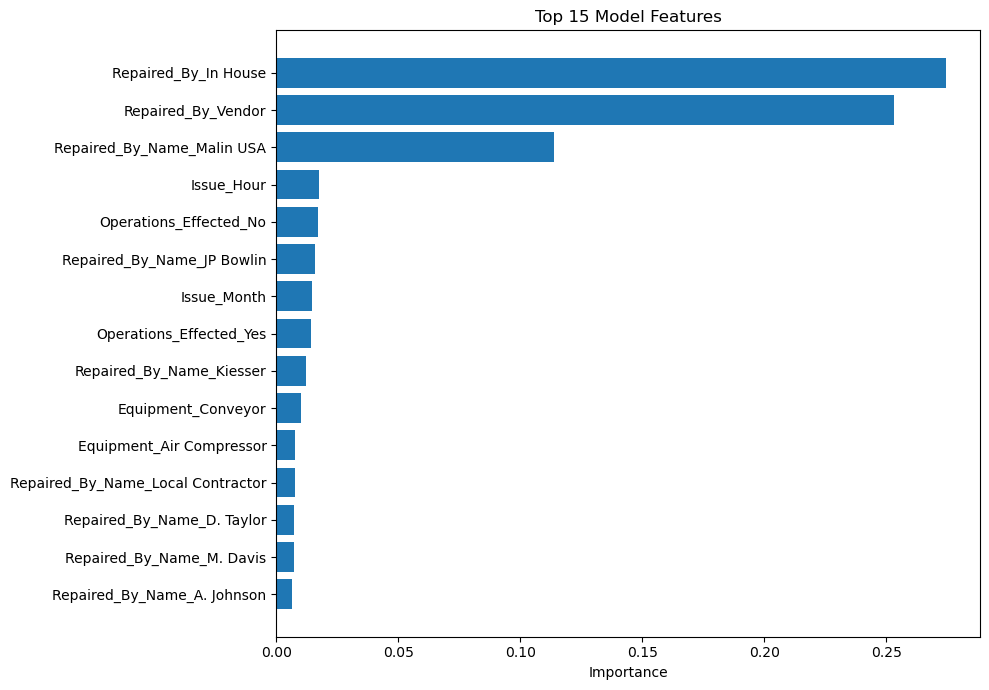

In [24]:
top_n = 15
plot_df = feature_importance_df.head(top_n).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["Feature"], plot_df["Importance"])
plt.title("Top 15 Model Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [25]:
df["Predicted_High_Downtime_Prob"] = model.predict_proba(X)[:, 1]
df["Predicted_High_Downtime"] = model.predict(X)

df[[
    "Equipment",
    "Warehouse_Location",
    "Issue",
    "Repaired_By",
    "Downtime_Hours",
    "High_Downtime",
    "Predicted_High_Downtime_Prob",
    "Predicted_High_Downtime"
]].head()

,Equipment,Warehouse_Location,Issue,Repaired_By,Downtime_Hours,High_Downtime,Predicted_High_Downtime_Prob,Predicted_High_Downtime
0,Robot,Bakersfield,Navigation Error,Vendor,66.0,1,0.960376,1
1,CubiScan,Nashville,Scale Drift,In House,19.0,0,0.057005,0
2,Wrap Machine,Fort Worth,Sensor Misalignment,In House,7.0,0,0.091443,0
3,Forklift,San Diego,Battery Failure,In House,3.0,0,0.001154,0
4,Pallet Rack,Nashville,Guard Rail Damage,In House,4.0,0,0.002356,0


In [26]:
risk_view = df[[
    "Equipment",
    "Warehouse_Location",
    "InHouse_Location",
    "Issue",
    "Repaired_By",
    "Repaired_By_Name",
    "Safety_Effected",
    "Operations_Effected",
    "Downtime_Hours",
    "High_Downtime",
    "Predicted_High_Downtime_Prob"
]].sort_values("Predicted_High_Downtime_Prob", ascending=False)

risk_view.head(20)

,Equipment,Warehouse_Location,InHouse_Location,Issue,Repaired_By,Repaired_By_Name,Safety_Effected,Operations_Effected,Downtime_Hours,High_Downtime,Predicted_High_Downtime_Prob
7461,Air Compressor,San Antonio,Shipping,Low Pressure,Vendor,Kiesser,No,Yes,83.0,1,1.000000
11034,Air Compressor,Fort Worth,VNA,Motor Overheat,Vendor,Kiesser,No,Yes,73.0,1,1.000000
19812,Air Compressor,San Diego,VNA,Motor Overheat,Vendor,Kiesser,No,Yes,85.0,1,1.000000
11017,Air Compressor,San Diego,Receiving,Motor Overheat,Vendor,Kiesser,No,Yes,84.0,1,1.000000
4600,Air Compressor,San Diego,Sortation,Filter Restriction,Vendor,Kiesser,No,Yes,27.0,1,1.000000
25649,Air Compressor,Fort Worth,VNA,Filter Restriction,Vendor,Kiesser,No,Yes,48.0,1,1.000000
8030,Conveyor,San Diego,Shipping,VFD Fault,Vendor,Malin USA,No,Yes,55.0,1,1.000000
17080,Air Compressor,Fort Worth,Shipping,Motor Overheat,Vendor,Kiesser,No,Yes,54.0,1,1.000000
25513,Air Compressor,San Antonio,VNA,Filter Restriction,Vendor,Kiesser,No,Yes,49.0,1,0.999943
26350,Air Compressor,Nashville,Office,Low Pressure,Vendor,Kiesser,No,Yes,46.0,1,0.999913


In [27]:
output_path = "warehouse_operations_scored_v2.csv"
risk_view.to_csv(output_path, index=False)
print(f"Saved scored file to: {output_path}")

Saved scored file to: warehouse_operations_scored_v2.csv
